In [1]:
import sys

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
indir='/home/hsher/scratch/circSTAMP_pipe/output/sailor/motif_apo_as_bg/'

regions = ['all', 'cds', 'distintron500', 'five_prime_utrs', 'proxintron500', 'three_prime_utrs']



In [2]:
lib = ['.'.join(f.split('.')[:-2]) for f in os.listdir(indir)]

In [3]:
set(lib)

{'HuR-1-A.vs.APO-1-A',
 'HuR-1-R.vs.APO-1-R',
 'HuR-50-A.vs.APO-50-A',
 'HuR-50-R.vs.APO-50-R',
 'HuR-noD-A.vs.APO-noD-A',
 'HuR-noD-R.vs.APO-noD-R'}

In [4]:

def homer_reader(fname):
    with open(fname) as f:
        flines = f.readlines()
        all_matrix = []
        all_fields = []
        motif_no = 0
        for line in flines:
            if line[0] == '>':
                if motif_no > 0:
                    all_matrix.append(pd.DataFrame(matrix_lines, columns= ['A', 'C', 'G', 'T']))
                    all_fields.append(fields)
                matrix_lines = []
                fields = dict(zip(['log odds', 'log pval'], [float(l) for l in line.split('\t')[2:4]]))
                motif_no += 1
            else:
                # matrix
                
                matrix_lines.append([float(l) for l in line.split('\t')])
    return all_matrix, all_fields
                
def plot_motif(df, label = '%', ax = None, title = ''):
    ''' df: index:[ATCG], col: integer pos '''
    import logomaker
    # top 20
    df.columns = np.arange(df.shape[1])
    ww_logo = logomaker.Logo(df.T,
                            vpad=.1,
                            width=.8,
                            ax = ax, )
    ww_logo.ax.set_ylabel(label)
    ax.set_title(title)
    ax.axis('off')
    

In [5]:
rc = {"axes.spines.left" : False,
      "axes.spines.right" : False,
      "axes.spines.bottom" : False,
      "axes.spines.top" : False,
      "xtick.bottom" : False,
      "xtick.labelbottom" : False,
      "ytick.labelleft" : False,
      "ytick.left" : False}
plt.rcParams.update(rc)
def plot_all_homer(lib, max_motif = 5):
    f, ax = plt.subplots(max_motif, len(regions), figsize = (14,5))
    for j, reg in enumerate(regions):
        
        try:
            motifs,attributes = homer_reader(os.path.join(indir, f'{lib}.{reg}.homer'))
            i = 0
            for motif, attr in zip(motifs, attributes):
                ax[i,j].axis('off')
                pv = attr['log pval']
                if i > 0:
                    plot_motif(motif.T, ax = ax[i, j], title = f'{pv:1f}')
                else:
                    plot_motif(motif.T, ax = ax[i, j], title = f'{reg}\n{pv:1f}')
                
                i+=1
        except Exception as e:
            print(e)
    plt.suptitle(lib)

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


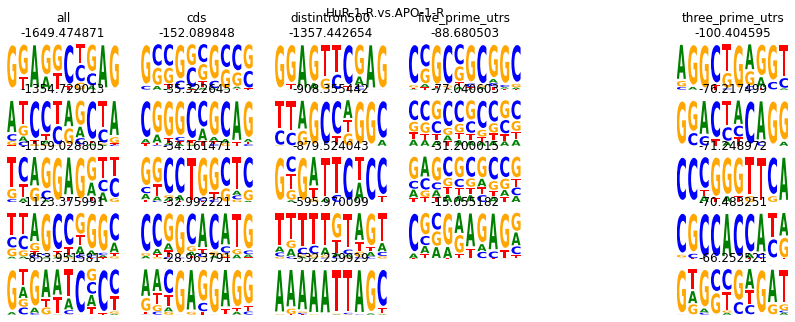

In [6]:
plot_all_homer('HuR-1-R.vs.APO-1-R')

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


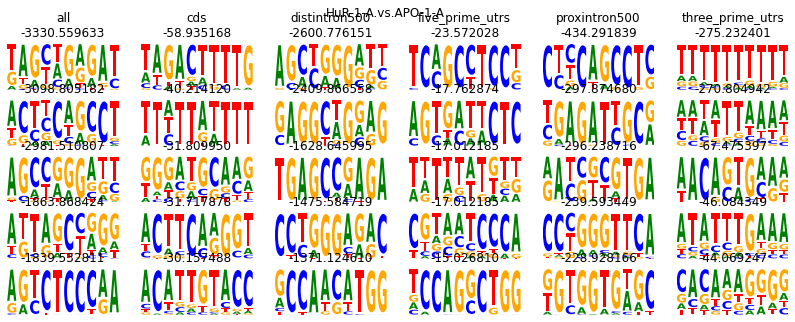

In [7]:
plot_all_homer('HuR-1-A.vs.APO-1-A')

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


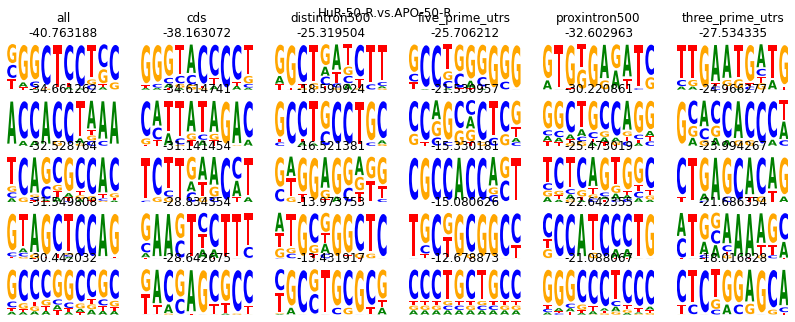

In [8]:
plot_all_homer('HuR-50-R.vs.APO-50-R')

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


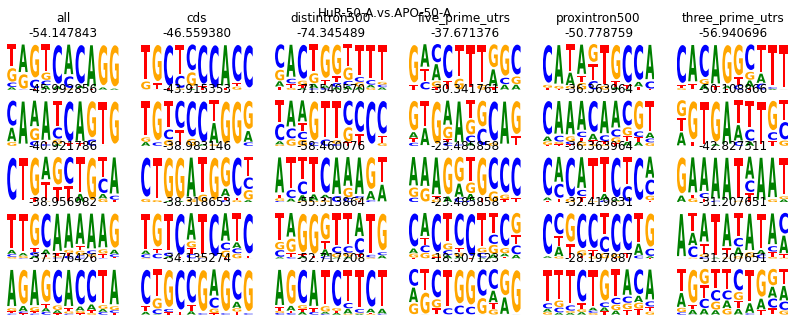

In [9]:
plot_all_homer('HuR-50-A.vs.APO-50-A')

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


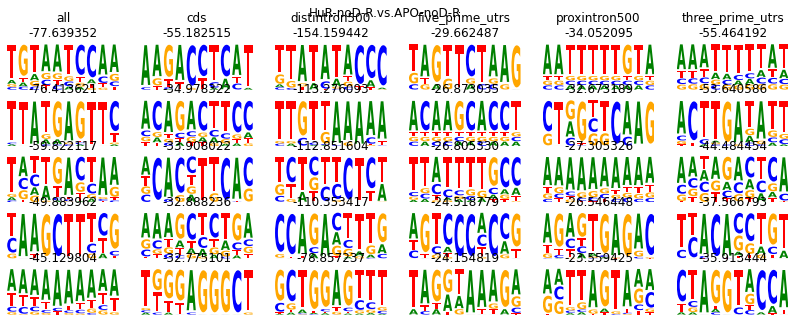

In [10]:
plot_all_homer('HuR-noD-R.vs.APO-noD-R')

index 5 is out of bounds for axis 0 with size 5
index 5 is out of bounds for axis 0 with size 5


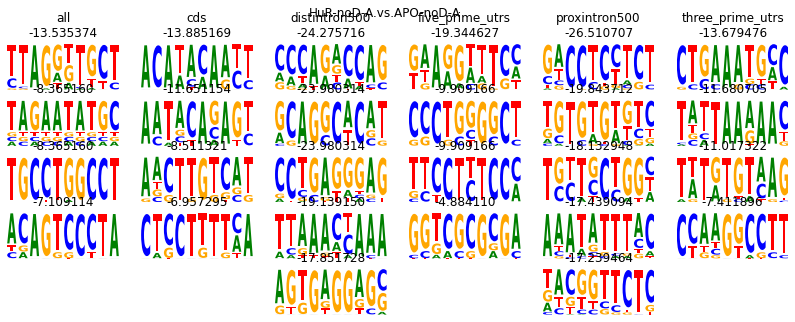

In [11]:
plot_all_homer('HuR-noD-A.vs.APO-noD-A')